In [ ]:
!pip install sentence-transformers seaborn matplotlib

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

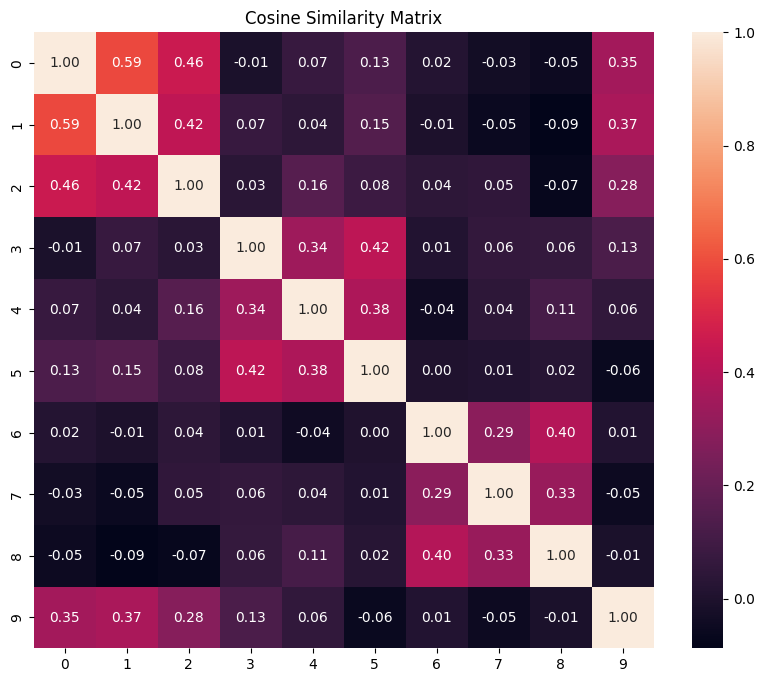


Top 2 similar sentences:
The bowler took a wicket in the final over (Score: 0.84)
The batsman scored a century in the match (Score: 0.57)


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# 10 sentences (3 topics)
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler took a wicket in the final over",
    "Cricket is a popular sport in India",

    # Cooking
    "Add spices to enhance the flavor of the dish",
    "Cooking requires patience and practice",
    "Boil the vegetables before adding them to the curry",

    # Cybersecurity
    "Cybersecurity protects systems from digital attacks",
    "Use strong passwords to secure your accounts",
    "Firewalls help prevent unauthorized access",

    # Extra
    "The match was exciting and full of surprises"
]

# Generate embeddings
embeddings = model.encode(sentences)

# Cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f")
plt.title("Cosine Similarity Matrix")
plt.show()

# Query sentence
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

# Compute similarity
scores = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 similar sentences
top_indices = scores.argsort()[-2:][::-1]

print("\nTop 2 similar sentences:")
for idx in top_indices:
    print(f"{sentences[idx]} (Score: {scores[idx]:.2f})")